# Image Captioning — Data & Training v5
**Architecture:** BLIP fine-tuned on Flickr8k  
**Changes from v4:**
- Dataset: use all 5 captions per image per epoch (not random 1) — 5x more text signal
- LR schedule: cosine warm restarts (T_0=5) instead of single decay — escapes plateau
- Patience raised to 6 to give restarts room to improve after each reset
- Everything else unchanged (label smoothing 0.1, frozen vision encoder, beam=8)


## 0. Install Dependencies

In [13]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip("transformers>=4.35", "accelerate")
print("Dependencies ready.")


Dependencies ready.


## 1. Imports & Setup

In [14]:
import os, re, math, json, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import BlipProcessor, BlipForConditionalGeneration

os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


PyTorch: 2.10.0+cu128
CUDA available: True
Device: cuda


## 2. Data Loading

In [15]:
import kagglehub

dataset_path = kagglehub.dataset_download('giorgicheishvili/caption-data')
dataset_path = Path(dataset_path)
print("Dataset root:", dataset_path)


Dataset root: /kaggle/input/datasets/giorgicheishvili/caption-data


In [16]:
IMAGES_DIR    = dataset_path / "Images"
CAPTIONS_FILE = dataset_path / "captions.txt"

if not IMAGES_DIR.exists():
    candidates = list(dataset_path.rglob("Images"))
    IMAGES_DIR = candidates[0] if candidates else dataset_path
if not CAPTIONS_FILE.exists():
    candidates = list(dataset_path.rglob("captions.txt"))
    CAPTIONS_FILE = candidates[0]

print("Images dir :", IMAGES_DIR)
print("Captions   :", CAPTIONS_FILE)
print("Image count:", len(list(IMAGES_DIR.glob("*.jpg"))))


Images dir : /kaggle/input/datasets/giorgicheishvili/caption-data/Images
Captions   : /kaggle/input/datasets/giorgicheishvili/caption-data/captions.txt
Image count: 8091


In [17]:
df = pd.read_csv(CAPTIONS_FILE)
df.columns = [c.strip() for c in df.columns]
df['image']   = df['image'].str.strip()
df['caption'] = df['caption'].str.strip()

print(f"Total rows   : {len(df)}")
print(f"Unique images: {df['image'].nunique()}")
df.head(6)


Total rows   : 40455
Unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting


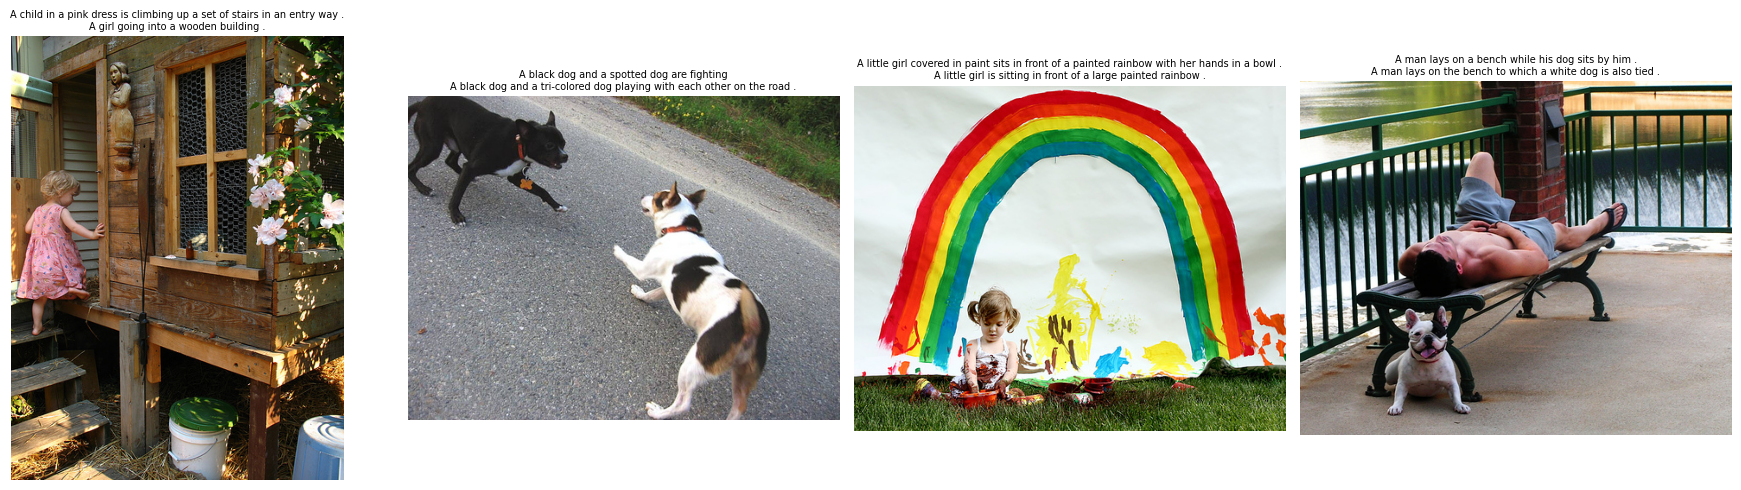

In [18]:
sample_imgs = df['image'].unique()[:4]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img_name in zip(axes, sample_imgs):
    img      = Image.open(IMAGES_DIR / img_name).convert("RGB")
    captions = df[df['image'] == img_name]['caption'].tolist()
    ax.imshow(img)
    ax.set_title("\n".join(captions[:2]), fontsize=7, wrap=True)
    ax.axis('off')
plt.tight_layout(); plt.show()


## 3. Load BLIP Processor & Model

`Salesforce/blip-image-captioning-base` is pre-trained on 129M image-text pairs.  
The processor handles both image pre-processing and text tokenisation in one object.


In [19]:
MODEL_NAME = "Salesforce/blip-image-captioning-base"

processor = BlipProcessor.from_pretrained(MODEL_NAME)
model     = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model          : {MODEL_NAME}")
print(f"Total params   : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Model          : Salesforce/blip-image-captioning-base
Total params   : 247,444,600
Trainable params: 247,444,600


## 4. Train / Validation Split

In [20]:
all_images = df['image'].unique().tolist()
random.shuffle(all_images)

split      = int(0.90 * len(all_images))
train_imgs = set(all_images[:split])
val_imgs   = set(all_images[split:])

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)

print(f"Train rows: {len(train_df)}  ({train_df['image'].nunique()} images)")
print(f"Val   rows: {len(val_df)}   ({val_df['image'].nunique()} images)")


Train rows: 36405  (7281 images)
Val   rows: 4050   (810 images)


## 5. Dataset & DataLoader

In [21]:
class FlickrDataset(Dataset):
    """
    Training: use ALL 5 captions per image every epoch, not just a random one.
    In v4 we sampled 1 caption per image → the model only saw 1/5 of the text
    signal per epoch. Using all 5 gives 5x more diverse caption-image pairs per
    epoch with zero extra compute cost on the vision side (same images).
    Validation: all rows as before.
    """
    def __init__(self, dataframe, images_dir, processor, use_all_captions=False):
        self.df               = dataframe.reset_index(drop=True)
        self.images_dir       = Path(images_dir)
        self.processor        = processor
        self.use_all_captions = use_all_captions

    def __len__(self):
        return len(self.df)   # always use every row

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = row["image"]
        caption  = row["caption"]

        image = Image.open(self.images_dir / img_name).convert("RGB")
        return image, caption


def collate_fn(batch):
    images, captions = zip(*batch)
    encoding = processor(
        images=list(images),
        text=list(captions),
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=64,
    )
    labels = encoding["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    encoding["labels"] = labels
    return encoding


BATCH_SIZE  = 16
NUM_WORKERS = 2

train_dataset = FlickrDataset(train_df, IMAGES_DIR, processor, use_all_captions=True)
val_dataset   = FlickrDataset(val_df,   IMAGES_DIR, processor, use_all_captions=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f"Train batches : {len(train_loader)}  (5 captions × {train_df['image'].nunique()} images)")
print(f"Val   batches : {len(val_loader)}")


Train batches : 2276  (5 captions × 7281 images)
Val   batches : 254


## 6. Training

### Strategy
- **Vision encoder frozen throughout** — unchanged from v4.
- **Full text decoder trains from epoch 1** at lr=1e-5 — unchanged.
- **All 5 captions per image** used every epoch — 5x more text signal than v4.
- **Cosine warm restarts (T_0=5 epochs)** — resets LR every 5 epochs so the model  
  can escape the plateau basin it got stuck in during v4 epochs 14–24.
- **Label smoothing ε=0.1** — unchanged.
- **Patience=6** — gives each restart cycle room to improve before stopping.


In [22]:
ACCUM_STEPS   = 4
NUM_EPOCHS    = 20
WARMUP_EPOCHS = 1
PATIENCE      = 6
LABEL_SMOOTH  = 0.1
T_0           = 5   # restart LR every 5 epochs

# Freeze vision encoder
for p in model.vision_model.parameters():
    p.requires_grad = False

# Full text decoder trains
for p in model.text_decoder.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"Trainable params : {trainable:,}")
print(f"Frozen params    : {frozen:,}  (vision encoder)")

# Deduplicate params (BLIP has tied weights)
seen, unique_params = set(), []
for p in model.parameters():
    if p.requires_grad and id(p) not in seen:
        unique_params.append(p)
        seen.add(id(p))

optimizer = torch.optim.AdamW(
    unique_params,
    lr=1e-5,
    weight_decay=1e-2,
    betas=(0.9, 0.98),
)

# Warmup for first epoch, then cosine warm restarts every T_0 epochs.
# Each restart resets LR back to 1e-5, letting the model escape
# the plateau basin it settled into toward the end of v4 training.
warmup_steps = WARMUP_EPOCHS * len(train_loader) // ACCUM_STEPS

def warmup_fn(step):
    if step < warmup_steps:
        return float(step) / max(1, warmup_steps)
    return 1.0

warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_fn)

restart_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=T_0 * len(train_loader) // ACCUM_STEPS,  # steps per restart cycle
    T_mult=1,
    eta_min=1e-6,
)

scaler = torch.amp.GradScaler("cuda")

print(f"Warmup steps       : {warmup_steps}")
print(f"Restart every      : {T_0} epochs")
print(f"Label smoothing    : {LABEL_SMOOTH}")


Trainable params : 161,354,104
Frozen params    : 86,090,496  (vision encoder)
Warmup steps       : 569
Restart every      : 5 epochs
Label smoothing    : 0.1


In [23]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*lr_scheduler.*")


def smooth_loss(logits, labels, smoothing=0.1, ignore_index=-100):
    """Cross-entropy with label smoothing."""
    vocab_size   = logits.size(-1)
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    mask         = (shift_labels != ignore_index)
    log_probs    = torch.nn.functional.log_softmax(shift_logits, dim=-1)
    nll          = -log_probs.gather(dim=-1, index=shift_labels.clamp(min=0).unsqueeze(-1)).squeeze(-1)
    smooth       = -log_probs.sum(dim=-1) / vocab_size
    loss         = (1 - smoothing) * nll + smoothing * smooth
    return loss[mask].mean()


# Global step counter for scheduler coordination
_global_step = 0

def train_one_epoch(model, loader, optimizer, warmup_sched, restart_sched,
                    scaler, device, accum_steps, warmup_steps):
    global _global_step
    model.train()
    total_loss, n_batches        = 0.0, 0
    correct_tokens, total_tokens = 0, 0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}

        with torch.amp.autocast("cuda"):
            outputs = model(**batch)
            loss    = smooth_loss(outputs.logits, batch["labels"],
                                  smoothing=LABEL_SMOOTH) / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            # During warmup use warmup scheduler, after use cosine restarts
            if _global_step < warmup_steps:
                warmup_sched.step()
            else:
                restart_sched.step()

            optimizer.zero_grad()
            _global_step += 1

        with torch.no_grad():
            shift_logits = outputs.logits[:, :-1, :].contiguous()
            shift_labels = batch["labels"][:, 1:].contiguous()
            preds = shift_logits.argmax(dim=-1)
            mask  = (shift_labels != -100)
            correct_tokens += (preds[mask] == shift_labels[mask]).sum().item()
            total_tokens   += mask.sum().item()
            total_loss     += loss.item() * accum_steps
            n_batches      += 1

    optimizer.zero_grad()
    return total_loss / max(n_batches, 1), correct_tokens / max(total_tokens, 1)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, n_batches        = 0.0, 0
    correct_tokens, total_tokens = 0, 0

    for batch in loader:
        batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
        with torch.amp.autocast("cuda"):
            outputs = model(**batch)
            loss    = smooth_loss(outputs.logits, batch["labels"], smoothing=LABEL_SMOOTH)

        shift_logits = outputs.logits[:, :-1, :].contiguous()
        shift_labels = batch["labels"][:, 1:].contiguous()
        preds = shift_logits.argmax(dim=-1)
        mask  = (shift_labels != -100)
        correct_tokens += (preds[mask] == shift_labels[mask]).sum().item()
        total_tokens   += mask.sum().item()
        total_loss     += loss.item()
        n_batches      += 1

    return total_loss / n_batches, correct_tokens / max(total_tokens, 1)


In [24]:
SAVE_DIR = Path("/kaggle/working")
SAVE_DIR.mkdir(exist_ok=True)

history = {
    "train_loss": [], "val_loss": [],
    "train_ppl":  [], "val_ppl":  [],
    "train_acc":  [], "val_acc":  [],
}
best_val_loss    = float("inf")
patience_counter = 0
_global_step     = 0   # reset for this run

print(
    f"{'Epoch':>6}  {'Tr Loss':>8}  {'Tr PPL':>7}  {'Tr Acc':>7}  "
    f"{'Val Loss':>9}  {'Val PPL':>8}  {'Val Acc':>8}  {'Time':>6}"
)
print("-" * 85)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer,
        warmup_scheduler, restart_scheduler,
        scaler, DEVICE, ACCUM_STEPS, warmup_steps
    )
    val_loss, val_acc = evaluate(model, val_loader, DEVICE)

    train_ppl = math.exp(min(train_loss, 20))
    val_ppl   = math.exp(min(val_loss,   20))
    elapsed   = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Mark restart epochs in output
    restart_marker = " ↺" if epoch > 1 and (epoch - 1) % T_0 == 0 else ""

    print(f"{epoch:>6}  {train_loss:>8.4f}  {train_ppl:>7.2f}  {train_acc:>6.2%}  "
          f"{val_loss:>9.4f}  {val_ppl:>8.2f}  {val_acc:>7.2%}  {elapsed:>5.0f}s{restart_marker}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        model.save_pretrained(str(SAVE_DIR / "best_model"))
        processor.save_pretrained(str(SAVE_DIR / "best_model"))
        print(f"         ✓ New best saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print("\nTraining complete.")
print(f"Best val loss : {best_val_loss:.4f}  |  Best val PPL: {math.exp(min(best_val_loss,20)):.2f}")


 Epoch   Tr Loss   Tr PPL   Tr Acc   Val Loss   Val PPL   Val Acc    Time
-------------------------------------------------------------------------------------
     1    3.6613    38.91  49.12%     3.2357     25.42   50.86%    869s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.2357)
     2    3.0173    20.44  56.27%     3.0122     20.33   55.95%    869s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=3.0122)
     3    2.8941    18.07  58.26%     2.9962     20.01   56.29%    870s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=2.9962)
     4    2.8301    16.95  59.46%     2.9934     19.95   56.34%    870s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

         ✓ New best saved (val_loss=2.9934)
     5    2.7870    16.23  60.35%     2.9951     19.99   56.40%    870s
     6    2.7632    15.85  60.87%     2.9977     20.04   56.29%    870s ↺
     7    2.7689    15.94  60.62%     3.0018     20.12   56.14%    870s
     8    2.7067    14.98  61.98%     3.0139     20.37   56.04%    883s
     9    2.6514    14.17  63.28%     3.0294     20.68   55.99%    869s
    10    2.6087    13.58  64.38%     3.0445     21.00   55.68%    870s

Early stopping at epoch 10.

Training complete.
Best val loss : 2.9934  |  Best val PPL: 19.95


## 7. Training Curves

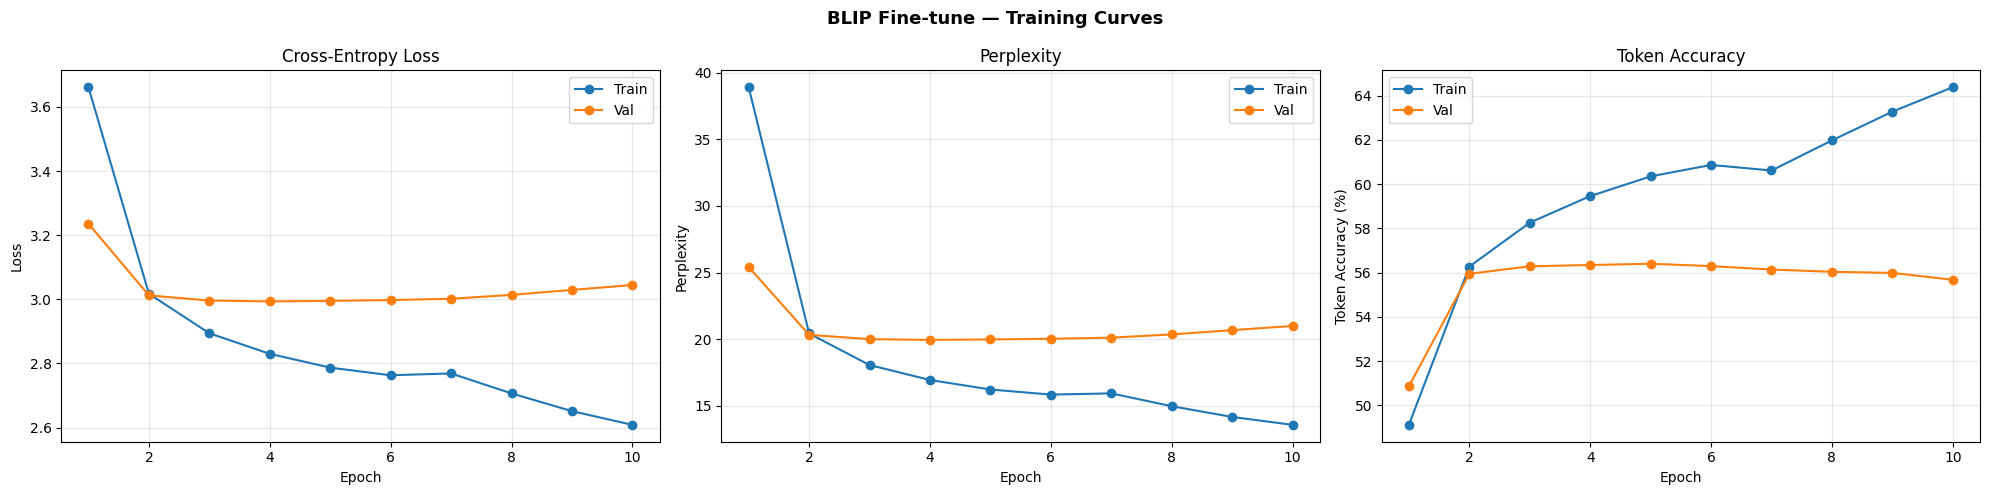

In [25]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val",   marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Cross-Entropy Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history["train_ppl"], label="Train", marker="o")
axes[1].plot(epochs_ran, history["val_ppl"],   label="Val",   marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_ran, [a * 100 for a in history["train_acc"]], label="Train", marker="o")
axes[2].plot(epochs_ran, [a * 100 for a in history["val_acc"]],   label="Val",   marker="o")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Token Accuracy (%)")
axes[2].set_title("Token Accuracy"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("BLIP Fine-tune — Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Caption Preview

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


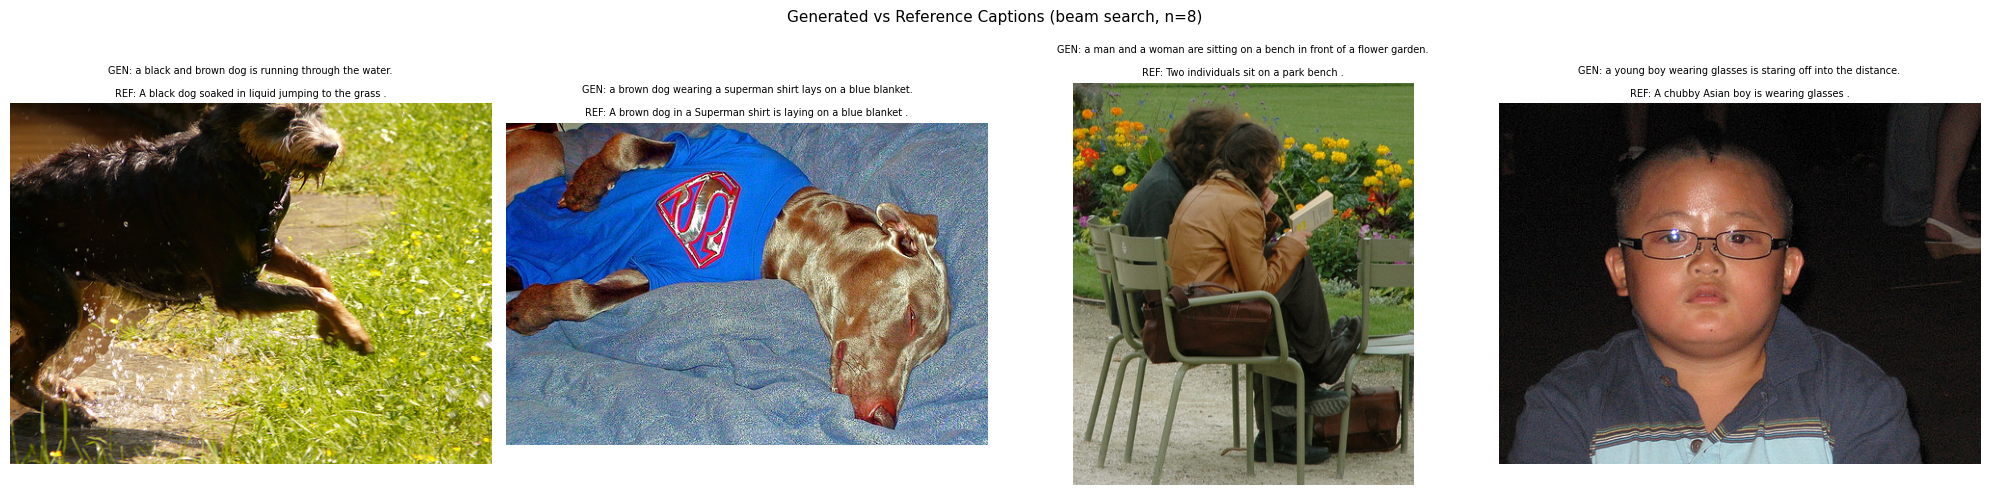

In [26]:
from transformers import BlipForConditionalGeneration as _BLIP

best_model     = _BLIP.from_pretrained(str(SAVE_DIR / 'best_model')).to(DEVICE)
best_processor = BlipProcessor.from_pretrained(str(SAVE_DIR / 'best_model'))
best_model.eval()

@torch.no_grad()
def generate_caption(image_path: str, model=best_model) -> str:
    """
    Takes a path to an image and returns a generated caption string.
    """
    image   = Image.open(image_path).convert("RGB")
    inputs  = best_processor(images=image, return_tensors="pt").to(DEVICE)
    out_ids = model.generate(**inputs, max_new_tokens=40, num_beams=8)
    return best_processor.decode(out_ids[0], skip_special_tokens=True)


sample_rows = val_df.drop_duplicates('image').sample(4, random_state=SEED)
fig, axes   = plt.subplots(1, 4, figsize=(20, 5))

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = str(IMAGES_DIR / row['image'])
    caption  = generate_caption(img_path)
    ref_caps = val_df[val_df['image'] == row['image']]['caption'].tolist()

    ax.imshow(Image.open(img_path))
    ax.set_title(f"GEN: {caption}\n\nREF: {ref_caps[0]}", fontsize=7, wrap=True)
    ax.axis('off')

plt.suptitle('Generated vs Reference Captions (beam search, n=8)', fontsize=11)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'caption_examples.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. BLEU-4 Evaluation

Compute BLEU-4 on the validation set — the standard metric for captioning on Flickr8k.  
Each generated caption is compared against all 5 human references for that image.


In [27]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nltk"])
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

best_model.eval()
val_images = val_df['image'].unique().tolist()

all_references = []
all_hypotheses = []

print(f"Evaluating BLEU-4 on {len(val_images)} validation images...")

for i, img_name in enumerate(val_images):
    img_path = str(IMAGES_DIR / img_name)
    caption  = generate_caption(img_path)

    refs = val_df[val_df['image'] == img_name]['caption'].tolist()
    ref_tokens  = [r.lower().split() for r in refs]
    hyp_tokens  = caption.lower().split()

    all_references.append(ref_tokens)
    all_hypotheses.append(hyp_tokens)

    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(val_images)} done...")

smoother = SmoothingFunction().method1
bleu4 = corpus_bleu(all_references, all_hypotheses,
                    weights=(0.25, 0.25, 0.25, 0.25),
                    smoothing_function=smoother)

print(f"\nBLEU-4 on validation set: {bleu4 * 100:.2f}")


Evaluating BLEU-4 on 810 validation images...
  100/810 done...
  200/810 done...
  300/810 done...
  400/810 done...
  500/810 done...
  600/810 done...
  700/810 done...
  800/810 done...

BLEU-4 on validation set: 30.44


## 10. Save Artifacts

In [28]:
with open(SAVE_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f)

print("Artifacts in:", SAVE_DIR)
print("  best_model/            — BLIP weights + processor (use with from_pretrained)")
print("  training_curves.png    — loss & perplexity plots")
print("  caption_examples.png   — sample generated captions")
print("  training_history.json  — per-epoch metrics")


Artifacts in: /kaggle/working
  best_model/            — BLIP weights + processor (use with from_pretrained)
  training_curves.png    — loss & perplexity plots
  caption_examples.png   — sample generated captions
  training_history.json  — per-epoch metrics
